In [2]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.3/85.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 133.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/1

In [14]:
from roboflow import Roboflow
rf = Roboflow(api_key="Dp4OixhO6CmgRo1pZM3T")
project = rf.workspace("wildlife-r6bnj").project("cow_train-pj9pi")
version = project.version(2)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Cow_train-2 in yolov8:: 100%|██████████| 509/509 [00:00<00:00, 6834.72it/s]


In [8]:
!pwd

/content


In [16]:
from ultralytics import YOLO

# Создаем новую модель YOLOv8n — самая легкая, но достаточно точная
model = YOLO("yolov8m.yaml")

# Обучение модели
model.train(data=f"/content/Cow_train-2/data.yaml", epochs=100, imgsz=640)


Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.yaml, data=/content/Cow_train-2/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, lin

train: Scanning /content/Cow_train-2/train/labels.cache... 200 images, 1 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 536.9±273.7 MB/s, size: 57.8 KB)


val: Scanning /content/Cow_train-2/valid/labels.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]


...

                   all         50       1283      0.602      0.429      0.454      0.143



100 epochs completed in 0.239 hours.
Optimizer stripped from runs/detect/train6/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train6/weights/best.pt, 52.0MB

Validating runs/detect/train6/weights/best.pt...
Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8m summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.66it/s]


                   all         50       1283      0.683      0.527      0.586      0.204
Speed: 0.2ms preprocess, 11.7ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs/detect/train6


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e32fc1c5010>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [22]:
model.export(format="onnx")        # универсально
model.export(format="torchscript") # для PyTorch backend
model.export(format="coreml")      # для iOS


Ultralytics 8.3.121 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.30GHz)
YOLOv8m summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from 'runs/detect/train6/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.46', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 301.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 176.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.8/280.8 MB 195.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 75.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 219.3 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 23.3s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim>=0.1.46', 'onnxruntime-gpu']
WARNING ⚠️ requirements: Restart runtime


CoreML: starting export with coremltools 8.3.0...


Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 89.76 passes/s]


CoreML: export success ✅ 27.2s, saved as 'runs/detect/train6/weights/best.mlpackage' (49.5 MB)

Export complete (31.0s)
Results saved to /content/runs/detect/train6/weights
Predict:         yolo predict task=detect model=runs/detect/train6/weights/best.mlpackage imgsz=640  
Validate:        yolo val task=detect model=runs/detect/train6/weights/best.mlpackage imgsz=640 data=/content/Cow_train-2/data.yaml  
Visualize:       https://netron.app


'runs/detect/train6/weights/best.mlpackage'

In [32]:
from ultralytics import YOLO

model = YOLO("runs/detect/train6/weights/best.pt")
results = model("/content/Cow_train-2/valid/images/frame_00000_png.rf.e5106cb3190d60e2d59dfdc364749046.jpg", show=True)


WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /content/Cow_train-2/valid/images/frame_00000_png.rf.e5106cb3190d60e2d59dfdc364749046.jpg: 640x640 17 cows, 37.0ms
Speed: 2.1ms preprocess, 37.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)



image 1/1 /content/Cow_train-2/valid/images/frame_00021_png.rf.0e0b474195405b5e61a0ad5f716d5479.jpg: 640x640 22 cows, 35.5ms
Speed: 2.3ms preprocess, 35.5ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 640)


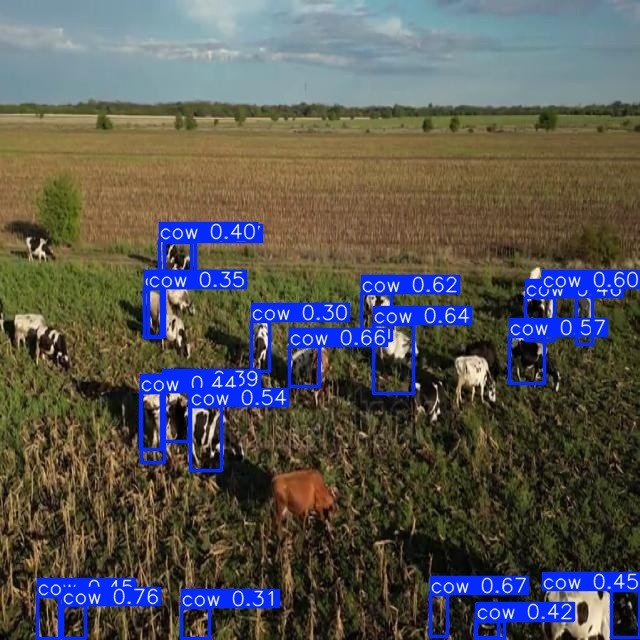

In [33]:
# Получаем изображение с предсказаниями
results = model("/content/Cow_train-2/valid/images/frame_00021_png.rf.0e0b474195405b5e61a0ad5f716d5479.jpg")

# Визуализация в блокноте
from IPython.display import Image, display
results[0].save(filename="pred.jpg")  # сохраняем предсказание
display(Image(filename="pred.jpg"))  # отображаем в Colab
